# 01 · Preparación del dataset D-Fire

Revisa el dataset D-Fire original y crea la versión que usan todos los
experimentos del TFM: corrige anotaciones con errores, comprueba que no haya
imágenes repetidas entre particiones y aparta el 10 % del entrenamiento como
validación.

## Guía de lectura y ejecución

| Aspecto | Descripción |
|---|---|
| **Papel en el proyecto** | Prepara la versión del dataset que usan todos los experimentos: revisa las anotaciones, corrige errores y crea las particiones. |
| **Cuándo abrirlo** | El primero, para ver cómo se prepararon los datos. |
| **Comportamiento por defecto** | No modifica nada (`RUN_PREPARATION=False`): carga y muestra la versión ya preparada. Necesita el dataset original en `data/D-Fire`. |
| **Entradas principales** | Dataset D-Fire original en `data/D-Fire`. |
| **Salidas principales** | `artifacts/datasets/dfire_seed42_val10_v1/` (incluida en el repositorio): listas de imágenes de cada partición, correcciones de anotaciones y ficheros `data.yaml`. |
| **Continuación** | `02_DFire_entrenamiento_modelos.ipynb`. |

> **Para ejecutarlo:** usar el entorno Docker de notebooks (sección 4 del
> `README.md` principal). Necesita el dataset D-Fire en `data/D-Fire`
> (sección 3 del `README.md` principal).

## Qué hace

1. Lee las carpetas `train` y `test` de `data/D-Fire` sin modificarlas.
2. Comprueba que cada imagen se puede abrir y que sus anotaciones tienen el
   formato correcto y las clases esperadas (0 = humo, 1 = fuego).
3. Recorta las cajas que se salen de la imagen, descarta las que no tienen
   tamaño y completa algunos JPEG a los que les falta el final del fichero.
   Cada corrección queda registrada en un CSV.
4. Busca imágenes idénticas repetidas en particiones distintas.
5. Aparta el 10 % del entrenamiento como validación, manteniendo la proporción
   de cada tipo de imagen (semilla 42).

Resultado: 15.500 imágenes de entrenamiento, 1.721 de validación y 4.306 de
test, guardadas en `artifacts/datasets/<DATASET_VERSION>`.

## 1. Parámetros

`RUN_PREPARATION=True` solo para crear de nuevo la versión preparada. Con
`False` se carga la versión que ya existe.

In [1]:
RUN_PREPARATION = False
DATASET_VERSION = "dfire_seed42_val10_v1"
VALIDATION_FRACTION = 0.10
SEED = 42
REPAIR_OUT_OF_BOUNDS_BOXES = True
DROP_DEGENERATE_BOXES = True
ALLOW_REBUILD = False
AUDIT_WORKERS = 8
NEAR_DUPLICATE_DISTANCE = 4  # Solo se conserva para las pruebas internas históricas.
MAX_NEAR_DUPLICATE_PAIRS = 200
CLASS_NAMES = {0: "smoke", 1: "fire"}
CLASS_COLORS = {0: "#F2C14E", 1: "#D62828"}


## 2. Entorno


In [11]:
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
import hashlib
import json
import math
import os
import random
import shutil
import tempfile
import warnings

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from PIL import Image, UnidentifiedImageError
from matplotlib.patches import Rectangle

import sys
roots = [Path(os.environ["TFM_PROJECT_ROOT"])] if os.environ.get("TFM_PROJECT_ROOT") else []
roots += [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in roots if (p / "tfm_pipeline.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Abrir el notebook dentro de la carpeta del proyecto o definir TFM_PROJECT_ROOT.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import tfm_pipeline as pipeline

PROJECT_ROOT = pipeline.project_root()
DATASET_ROOT = pipeline.dataset_root(PROJECT_ROOT)
PREPARED_ROOT = pipeline.prepared_root(PROJECT_ROOT, DATASET_VERSION)
EXECUTION_ROOT = PREPARED_ROOT
random.seed(SEED)
np.random.seed(SEED)

print(f"Dataset original: {DATASET_ROOT}")
print(f"Versión preparada: {PREPARED_ROOT}")


Dataset original: /workspace/TFM/data/D-Fire
Versión preparada: /workspace/TFM/artifacts/datasets/dfire_seed42_val10_v1


## 3. Funciones de revisión

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SPLIT_ALIASES = {
    "train": ("train", "training"),
    "val": ("val", "valid", "validation"),
    "test": ("test", "testing"),
}


class DatasetAuditError(RuntimeError):
    """Error que impide utilizar el dataset de forma fiable."""


def validate_class_mapping(class_names):
    expected = {0: "smoke", 1: "fire"}
    normalized = {int(key): str(value).lower() for key, value in class_names.items()}
    if normalized != expected:
        raise DatasetAuditError(
            f"Mapeo incorrecto: {normalized}. D-Fire requiere {expected}."
        )
    return True


def _case_insensitive_child(parent, candidate_names):
    if not parent.exists():
        return None
    children = {child.name.lower(): child for child in parent.iterdir() if child.is_dir()}
    for name in candidate_names:
        if name.lower() in children:
            return children[name.lower()]
    return None


def resolve_split_layout(dataset_root):
    """Localiza las particiones oficiales train/test sin alterar el dataset."""
    dataset_root = Path(dataset_root)
    if not dataset_root.exists():
        raise FileNotFoundError(
            f"No existe DATASET_ROOT: {dataset_root}\n"
            "Descarga la partición oficial desde "
            "https://github.com/gaia-solutions-on-demand/DFireDataset y revisa la celda de parámetros."
        )

    layout = {}
    for canonical_split in ("train", "test"):
        aliases = SPLIT_ALIASES[canonical_split]
        split_dir = _case_insensitive_child(dataset_root, aliases)
        images_dir = _case_insensitive_child(split_dir, ("images",)) if split_dir else None
        labels_dir = _case_insensitive_child(split_dir, ("labels",)) if split_dir else None

        if images_dir is None or labels_dir is None:
            images_root = _case_insensitive_child(dataset_root, ("images",))
            labels_root = _case_insensitive_child(dataset_root, ("labels",))
            images_dir = _case_insensitive_child(images_root, aliases) if images_root else None
            labels_dir = _case_insensitive_child(labels_root, aliases) if labels_root else None

        if images_dir is None or labels_dir is None:
            raise DatasetAuditError(
                f"No se localizaron images/ y labels/ para '{canonical_split}' bajo {dataset_root}. "
                "La descarga oficial debe contener train y test."
            )
        layout[canonical_split] = {"images": images_dir, "labels": labels_dir}
    return layout


def list_images(images_dir):
    return sorted(
        path for path in Path(images_dir).iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def parse_yolo_label(
    label_path,
    repair_out_of_bounds=False,
    repair_events=None,
    drop_degenerate=False,
    dropped_events=None,
):
    """Valida YOLO y, si se solicita, recorta solo cajas que cruzan el borde."""
    label_path = Path(label_path)
    if not label_path.exists() or label_path.stat().st_size == 0:
        return []

    boxes = []
    for line_number, raw_line in enumerate(
        label_path.read_text(encoding="utf-8-sig").splitlines(), start=1
    ):
        line = raw_line.strip()
        if not line:
            continue
        tokens = line.split()
        if len(tokens) != 5:
            raise DatasetAuditError(
                f"{label_path.name}:{line_number}: se esperaban 5 campos y hay {len(tokens)}."
            )
        try:
            values = [float(token) for token in tokens]
        except ValueError as exc:
            raise DatasetAuditError(
                f"{label_path.name}:{line_number}: hay valores no numéricos."
            ) from exc

        if not all(math.isfinite(value) for value in values):
            raise DatasetAuditError(
                f"{label_path.name}:{line_number}: contiene NaN o infinito."
            )

        raw_class, x_center, y_center, width, height = values
        if not raw_class.is_integer():
            raise DatasetAuditError(
                f"{label_path.name}:{line_number}: la clase debe ser un entero."
            )
        class_id = int(raw_class)
        if class_id not in CLASS_NAMES:
            raise DatasetAuditError(
                f"{label_path.name}:{line_number}: clase {class_id} fuera de {sorted(CLASS_NAMES)}."
            )
        if not (0 <= x_center <= 1 and 0 <= y_center <= 1):
            raise DatasetAuditError(
                f"{label_path.name}:{line_number}: centro fuera de [0, 1]."
            )
        if not (width > 0 and height > 0):
            if not drop_degenerate:
                raise DatasetAuditError(
                    f"{label_path.name}:{line_number}: ancho/alto debe ser positivo."
                )
            if dropped_events is not None:
                dropped_events.append({
                    "label_path": str(label_path.resolve()),
                    "line_number": line_number,
                    "class_id": class_id,
                    "x_center": x_center,
                    "y_center": y_center,
                    "width": width,
                    "height": height,
                    "reason": "degenerate_non_positive_area",
                })
            continue

        x1, y1 = x_center - width / 2, y_center - height / 2
        x2, y2 = x_center + width / 2, y_center + height / 2
        tolerance = 1e-9
        if min(x1, y1) < -tolerance or max(x2, y2) > 1 + tolerance:
            if not repair_out_of_bounds:
                raise DatasetAuditError(
                    f"{label_path.name}:{line_number}: la caja sale de la imagen."
                )
            clipped_x1, clipped_y1 = max(0.0, x1), max(0.0, y1)
            clipped_x2, clipped_y2 = min(1.0, x2), min(1.0, y2)
            if clipped_x2 <= clipped_x1 or clipped_y2 <= clipped_y1:
                raise DatasetAuditError(
                    f"{label_path.name}:{line_number}: la caja queda vacía al recortarla."
                )
            clipped_box = (
                class_id,
                (clipped_x1 + clipped_x2) / 2,
                (clipped_y1 + clipped_y2) / 2,
                clipped_x2 - clipped_x1,
                clipped_y2 - clipped_y1,
            )
            if repair_events is not None:
                repair_events.append({
                    "label_path": str(label_path.resolve()),
                    "line_number": line_number,
                    "class_id": class_id,
                    "original_x_center": x_center,
                    "original_y_center": y_center,
                    "original_width": width,
                    "original_height": height,
                    "clipped_x_center": clipped_box[1],
                    "clipped_y_center": clipped_box[2],
                    "clipped_width": clipped_box[3],
                    "clipped_height": clipped_box[4],
                    "max_normalized_overflow": max(
                        0.0, -x1, -y1, x2 - 1, y2 - 1
                    ),
                })
            boxes.append(clipped_box)
        else:
            boxes.append((class_id, x_center, y_center, width, height))
    return boxes


def image_sha256(image_path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(image_path).open("rb") as image_file:
        while chunk := image_file.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def jpeg_missing_end_marker(image_path, image_format):
    image_path = Path(image_path)
    if str(image_format).upper() not in {"JPG", "JPEG"}:
        return False
    with image_path.open("rb") as image_file:
        image_file.seek(-2, 2)
        return image_file.read() != b"\xff\xd9"


def difference_hash_from_image(image, hash_size=8):
    grayscale = image.convert("L").resize(
        (hash_size + 1, hash_size), Image.Resampling.LANCZOS
    )
    pixels = np.asarray(grayscale)
    differences = pixels[:, 1:] > pixels[:, :-1]
    value = 0
    for bit in differences.flatten():
        value = (value << 1) | int(bit)
    return value


def inspect_image(image_path):
    """Decodifica una vez para validar, obtener tamaño y calcular dHash."""
    with Image.open(image_path) as image:
        image_format = image.format
        image.load()
        width, height = image.size
        dhash = difference_hash_from_image(image)
    return width, height, dhash, image_format


def hamming_distance(hash_a, hash_b):
    return int(hash_a ^ hash_b).bit_count()


def image_category(boxes):
    classes = {box[0] for box in boxes}
    if classes == {0, 1}:
        return "smoke+fire"
    if classes == {0}:
        return "smoke"
    if classes == {1}:
        return "fire"
    return "background"


def _audit_image_record(
    split_name, image_path, labels_dir, repair_out_of_bounds, drop_degenerate
):
    label_path = Path(labels_dir) / f"{image_path.stem}.txt"
    repair_events = []
    dropped_events = []
    try:
        width, height, dhash, image_format = inspect_image(image_path)
        boxes = parse_yolo_label(
            label_path,
            repair_out_of_bounds=repair_out_of_bounds,
            repair_events=repair_events,
            drop_degenerate=drop_degenerate,
            dropped_events=dropped_events,
        )
        for event in repair_events:
            original_x1 = event["original_x_center"] - event["original_width"] / 2
            original_y1 = event["original_y_center"] - event["original_height"] / 2
            original_x2 = event["original_x_center"] + event["original_width"] / 2
            original_y2 = event["original_y_center"] + event["original_height"] / 2
            event.update({
                "official_split": split_name,
                "image_path": str(image_path.resolve()),
                "image_width": width,
                "image_height": height,
                "max_pixel_overflow": max(
                    0.0,
                    -original_x1 * width,
                    (original_x2 - 1) * width,
                    -original_y1 * height,
                    (original_y2 - 1) * height,
                ),
            })
        for event in dropped_events:
            event.update({
                "official_split": split_name,
                "image_path": str(image_path.resolve()),
                "image_width": width,
                "image_height": height,
            })
        record = {
            "split": split_name,
            "image_path": str(image_path.resolve()),
            "label_path": str(label_path.resolve()),
            "filename": image_path.name,
            "width": width,
            "height": height,
            "image_format": image_format,
            "aspect_ratio": width / height if height else np.nan,
            "label_exists": label_path.exists(),
            "label_empty": label_path.exists() and label_path.stat().st_size == 0,
            "box_count": len(boxes),
            "smoke_boxes": sum(box[0] == 0 for box in boxes),
            "fire_boxes": sum(box[0] == 1 for box in boxes),
            "source_smoke_boxes": sum(box[0] == 0 for box in boxes) + sum(
                event["class_id"] == 0 for event in dropped_events
            ),
            "source_fire_boxes": sum(box[0] == 1 for box in boxes) + sum(
                event["class_id"] == 1 for event in dropped_events
            ),
            "category": image_category(boxes),
            "sha256": image_sha256(image_path),
            "dhash": dhash,
            "repaired_boxes": len(repair_events),
            "dropped_degenerate_boxes": len(dropped_events),
            "jpeg_missing_eoi": jpeg_missing_end_marker(image_path, image_format),
        }
        return record, None, repair_events, dropped_events
    except (OSError, UnidentifiedImageError, DatasetAuditError) as exc:
        error = {
            "split": split_name,
            "file": str(image_path),
            "error": str(exc),
        }
        return None, error, [], []


def audit_split(
    split_name,
    images_dir,
    labels_dir,
    repair_out_of_bounds=False,
    drop_degenerate=False,
):
    images = list_images(images_dir)
    records, errors, repairs, dropped = [], [], [], []

    if not images:
        errors.append({
            "split": split_name,
            "file": str(images_dir),
            "error": "La partición no contiene imágenes compatibles.",
        })

    image_stems = [image_path.stem for image_path in images]
    duplicated_stems = pd.Series(image_stems).value_counts()
    for stem in duplicated_stems[duplicated_stems > 1].index:
        errors.append({
            "split": split_name,
            "file": stem,
            "error": "Varias imágenes comparten el mismo nombre base.",
        })

    image_stem_set = set(image_stems)
    orphan_labels = sorted(
        label_path for label_path in Path(labels_dir).iterdir()
        if label_path.is_file() and label_path.suffix.lower() == ".txt"
        if label_path.stem not in image_stem_set
    )
    for label_path in orphan_labels:
        errors.append({
            "split": split_name,
            "file": str(label_path),
            "error": "Etiqueta sin imagen correspondiente.",
        })

    worker_arguments = (
        (split_name, image_path, labels_dir, repair_out_of_bounds, drop_degenerate)
        for image_path in images
    )
    with ThreadPoolExecutor(max_workers=max(1, AUDIT_WORKERS)) as executor:
        results = executor.map(lambda args: _audit_image_record(*args), worker_arguments)
        for position, (record, error, image_repairs, image_dropped) in enumerate(
            results, start=1
        ):
            if record is not None:
                records.append(record)
            if error is not None:
                errors.append(error)
            repairs.extend(image_repairs)
            dropped.extend(image_dropped)
            if position % 1000 == 0 or position == len(images):
                print(f"  {split_name}: {position:,}/{len(images):,} imágenes")
    return pd.DataFrame(records), errors, repairs, dropped


def create_validation_split(official_train_manifest, validation_fraction=0.10, seed=42):
    """Divide el train oficial por categoría y mantiene juntos duplicados exactos."""
    if not 0 < validation_fraction < 1:
        raise ValueError("VALIDATION_FRACTION debe estar entre 0 y 1.")
    if official_train_manifest.empty:
        raise DatasetAuditError("El entrenamiento oficial está vacío.")

    result = official_train_manifest.copy()
    result["official_split"] = "train"
    result["split"] = "train"

    inconsistent_hashes = (
        result.groupby("sha256")["category"].nunique().loc[lambda values: values > 1]
    )
    if not inconsistent_hashes.empty:
        raise DatasetAuditError(
            "Hay imágenes idénticas con categorías incompatibles en el train oficial."
        )

    random_generator = random.Random(seed)
    validation_indices = []
    allocation_rows = []
    for category in sorted(result["category"].unique()):
        category_rows = result[result["category"] == category]
        groups = [list(indices) for _, indices in category_rows.groupby("sha256").groups.items()]
        random_generator.shuffle(groups)
        target = int(round(len(category_rows) * validation_fraction))
        selected_count = 0
        selected_groups = 0
        for group_indices in groups:
            if selected_count >= target:
                break
            validation_indices.extend(group_indices)
            selected_count += len(group_indices)
            selected_groups += 1
        allocation_rows.append({
            "category": category,
            "official_train_images": int(len(category_rows)),
            "validation_target": target,
            "validation_actual": selected_count,
            "validation_exact_hash_groups": selected_groups,
        })

    result.loc[validation_indices, "split"] = "val"
    if set(result["split"].unique()) != {"train", "val"}:
        raise DatasetAuditError("No se pudieron crear train y val internos.")
    return result, pd.DataFrame(allocation_rows)


def write_image_manifest(records, destination):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    # absolute() conserva la ruta de la vista; resolve() seguiría el enlace al original.
    image_paths = sorted(str(Path(path).absolute()) for path in records["image_path"])
    destination.write_text("\n".join(image_paths) + "\n", encoding="utf-8")
    return destination


def _link_image_without_copy(source, destination):
    source, destination = Path(source), Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.link(source, destination)
        return "hardlink"
    except OSError as hardlink_error:
        try:
            destination.symlink_to(source)
            return "symlink"
        except OSError as symlink_error:
            raise DatasetAuditError(
                f"No se pudo enlazar {source} sin duplicar la imagen. "
                f"Hardlink: {hardlink_error}; symlink: {symlink_error}."
            ) from symlink_error


def _format_yolo_box(box):
    class_id, *coordinates = box
    return f"{int(class_id)} " + " ".join(format(value, ".17g") for value in coordinates)


def _create_directory_link(source, destination):
    source, destination = Path(source).absolute(), Path(destination).absolute()
    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.symlink_to(source, target_is_directory=True)


def materialize_dataset_view(manifest, repair_events, dropped_events, destination_root):
    """Crea una vista corregida, copiando solo JPEG reparables, sin alterar D-Fire."""
    prepared = manifest.copy()
    prepared["source_image_path"] = prepared["image_path"]
    prepared["source_label_path"] = prepared["label_path"]
    destination_root = Path(destination_root).absolute()
    prepared_labels_root = destination_root / "prepared_labels"

    for official_split in ("train", "test"):
        official_rows = prepared[prepared["official_split"] == official_split]
        source_labels_dir = Path(official_rows.iloc[0]["source_label_path"]).parent
        shutil.copytree(
            source_labels_dir, prepared_labels_root / official_split
        )
        print(f"  etiquetas oficiales {official_split}: copiadas")

    edits_by_label = defaultdict(lambda: {"repairs": {}, "drops": set(), "split": None})
    for event in repair_events:
        actions = edits_by_label[event["label_path"]]
        actions["repairs"][int(event["line_number"])] = event
        actions["split"] = event["official_split"]
    for event in dropped_events:
        actions = edits_by_label[event["label_path"]]
        actions["drops"].add(int(event["line_number"]))
        actions["split"] = event["official_split"]

    for source_label_path, actions in edits_by_label.items():
        source_label = Path(source_label_path)
        destination_label = prepared_labels_root / actions["split"] / source_label.name
        lines = source_label.read_text(encoding="utf-8-sig").splitlines()
        for line_number, event in actions["repairs"].items():
            clipped_box = (
                event["class_id"],
                event["clipped_x_center"],
                event["clipped_y_center"],
                event["clipped_width"],
                event["clipped_height"],
            )
            lines[line_number - 1] = _format_yolo_box(clipped_box)
        for line_number in actions["drops"]:
            lines[line_number - 1] = None
        retained_lines = [line for line in lines if line is not None]
        label_text = "\n".join(retained_lines)
        destination_label.write_text(
            label_text + ("\n" if label_text else ""), encoding="utf-8"
        )
        parse_yolo_label(destination_label)

    logical_to_official = {"train": "train", "val": "train", "test": "test"}
    if os.name != "nt":
        for logical_split, official_split in logical_to_official.items():
            _create_directory_link(
                prepared_labels_root / official_split,
                destination_root / "labels" / logical_split,
            )

    image_link_methods = []
    for position, row in enumerate(prepared.itertuples(), start=1):
        source_image = Path(row.source_image_path)
        destination_image = destination_root / "images" / row.split / source_image.name
        destination_image.parent.mkdir(parents=True, exist_ok=True)
        if bool(row.jpeg_missing_eoi):
            shutil.copy2(source_image, destination_image)
            image_link_methods.append("copy_for_missing_jpeg_eoi")
        else:
            image_link_methods.append(
                _link_image_without_copy(source_image, destination_image)
            )

        if os.name == "nt":
            source_prepared_label = (
                prepared_labels_root / row.official_split / f"{source_image.stem}.txt"
            )
            destination_label = (
                destination_root / "labels" / row.split / source_prepared_label.name
            )
            destination_label.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(source_prepared_label, destination_label)
        if position % 5000 == 0 or position == len(prepared):
            print(f"  imágenes preparadas: {position:,}/{len(prepared):,}")

    prepared["image_path"] = [
        str(destination_root / "images" / row.split / row.filename)
        for row in prepared.itertuples()
    ]
    prepared["label_path"] = [
        str(destination_root / "labels" / row.split / f"{Path(row.filename).stem}.txt")
        for row in prepared.itertuples()
    ]
    prepared["image_link_method"] = image_link_methods
    link_summary = pd.Series(image_link_methods).value_counts().to_dict()
    print(f"  vista derivada lista: {len(prepared):,} imágenes; {link_summary}")
    return prepared


def find_cross_split_exact_duplicates(manifest):
    duplicated = manifest.groupby("sha256").filter(
        lambda group: group["split"].nunique() > 1
    )
    return duplicated.sort_values(["sha256", "split", "filename"]).reset_index(drop=True)


class BKTree:
    """Índice para buscar hashes perceptuales por distancia de Hamming."""

    def __init__(self):
        self.root = None

    def add(self, hash_value, row_index):
        if self.root is None:
            self.root = [hash_value, [row_index], {}]
            return
        node = self.root
        while True:
            distance = hamming_distance(hash_value, node[0])
            if distance == 0:
                node[1].append(row_index)
                return
            if distance not in node[2]:
                node[2][distance] = [hash_value, [row_index], {}]
                return
            node = node[2][distance]

    def query(self, hash_value, max_distance):
        if self.root is None:
            return []
        matches, stack = [], [self.root]
        while stack:
            node = stack.pop()
            distance = hamming_distance(hash_value, node[0])
            if distance <= max_distance:
                matches.extend((distance, index) for index in node[1])
            lower, upper = distance - max_distance, distance + max_distance
            stack.extend(
                child for edge, child in node[2].items()
                if lower <= edge <= upper
            )
        return matches


def find_near_duplicates(manifest, max_distance=4, max_pairs=200):
    pairs = []
    split_pairs = (("train", "val"), ("train", "test"), ("val", "test"))
    for left_split, right_split in split_pairs:
        left = manifest[manifest["split"] == left_split]
        right = manifest[manifest["split"] == right_split]
        tree = BKTree()
        for index, row in left.iterrows():
            tree.add(int(row["dhash"]), index)
        split_pair_count = 0
        split_pair_limit_reached = False
        for right_index, right_row in right.iterrows():
            for distance, left_index in tree.query(int(right_row["dhash"]), max_distance):
                left_row = manifest.loc[left_index]
                if left_row["sha256"] == right_row["sha256"]:
                    continue
                pairs.append({
                    "left_split": left_split,
                    "left_image": left_row["image_path"],
                    "right_split": right_split,
                    "right_image": right_row["image_path"],
                    "hamming_distance": distance,
                })
                split_pair_count += 1
                if split_pair_count >= max_pairs:
                    split_pair_limit_reached = True
                    break
            if split_pair_limit_reached:
                break
    return pd.DataFrame(pairs)


def resolve_resume_checkpoint(runs_root, explicit_checkpoint=None):
    if explicit_checkpoint is not None:
        checkpoint = Path(explicit_checkpoint)
        if not checkpoint.exists():
            raise FileNotFoundError(f"No existe el checkpoint indicado: {checkpoint}")
        return checkpoint
    candidates = list(Path(runs_root).rglob("last.pt"))
    if not candidates:
        raise FileNotFoundError(
            "RESUME_TRAINING=True pero no se ha encontrado ningún last.pt."
        )
    return max(candidates, key=lambda path: path.stat().st_mtime)


### 3.1 Pruebas de las funciones

Comprueba con ejemplos pequeños que las funciones de revisión detectan los
errores esperados.

In [4]:
validate_class_mapping(CLASS_NAMES)

with tempfile.TemporaryDirectory() as temporary_directory:
    temporary_path = Path(temporary_directory)

    valid_label = temporary_path / "valid.txt"
    valid_label.write_text(
        "0 0.5 0.5 0.2 0.2\n1 0.4 0.6 0.1 0.3\n", encoding="utf-8"
    )
    assert len(parse_yolo_label(valid_label)) == 2

    for filename, content in {
        "invalid_class.txt": "2 0.5 0.5 0.2 0.2\n",
        "outside_box.txt": "0 0.95 0.5 0.2 0.2\n",
        "degenerate.txt": "1 0.5 0.5 0.0 0.2\n",
        "invalid_fields.txt": "0 0.5 0.5 0.2\n",
    }.items():
        test_label = temporary_path / filename
        test_label.write_text(content, encoding="utf-8")
        try:
            parse_yolo_label(test_label)
            raise AssertionError(f"{filename} debía producir DatasetAuditError")
        except DatasetAuditError:
            pass

    repair_events = []
    repaired_boxes = parse_yolo_label(
        temporary_path / "outside_box.txt",
        repair_out_of_bounds=True,
        repair_events=repair_events,
    )
    assert len(repair_events) == 1
    _, repaired_x, _, repaired_w, _ = repaired_boxes[0]
    assert repaired_x + repaired_w / 2 <= 1

    dropped_events = []
    assert parse_yolo_label(
        temporary_path / "degenerate.txt",
        drop_degenerate=True,
        dropped_events=dropped_events,
    ) == []
    assert len(dropped_events) == 1

    try:
        validate_class_mapping({0: "fire", 1: "smoke"})
        raise AssertionError("El mapeo invertido debía bloquearse.")
    except DatasetAuditError:
        pass

    duplicate_manifest = pd.DataFrame([
        {"split": "train", "sha256": "same", "filename": "a.jpg"},
        {"split": "test", "sha256": "same", "filename": "b.jpg"},
    ])
    assert len(find_cross_split_exact_duplicates(duplicate_manifest)) == 2

    synthetic_train = pd.DataFrame([
        {"image_path": "a.jpg", "sha256": "duplicate", "category": "background"},
        {"image_path": "b.jpg", "sha256": "duplicate", "category": "background"},
        {"image_path": "c.jpg", "sha256": "unique-c", "category": "background"},
        {"image_path": "d.jpg", "sha256": "unique-d", "category": "background"},
    ])
    synthetic_split, _ = create_validation_split(synthetic_train, 0.5, SEED)
    assert synthetic_split.groupby("sha256")["split"].nunique().max() == 1
    assert set(synthetic_split["split"]) == {"train", "val"}

    checkpoint = temporary_path / "last.pt"
    checkpoint.touch()
    assert resolve_resume_checkpoint(temporary_path) == checkpoint

print("OK: pruebas internas superadas.")


OK: pruebas internas superadas.


## 4. Crear o cargar la versión preparada

In [5]:
if RUN_PREPARATION:
    completed_contract = (
        (PREPARED_ROOT / "dataset_manifest.csv").exists()
        and (PREPARED_ROOT / "split_metadata.json").exists()
        and (PREPARED_ROOT / "data.yaml").exists()
    )
    incomplete_view = PREPARED_ROOT / "dataset"
    if not completed_contract and incomplete_view.exists():
        print(f"Eliminando vista parcial de una ejecución interrumpida: {incomplete_view}")
        shutil.rmtree(incomplete_view, ignore_errors=True)
        if incomplete_view.exists():
            warnings.warn(
                "Windows mantiene algunos enlaces de la vista parcial. Se ignorarán: "
                "el contrato compacto no los utiliza."
            )
    if completed_contract and not ALLOW_REBUILD:
        raise FileExistsError(
            f"La versión {DATASET_VERSION} ya existe. Déjala inmutable y usa "
            "RUN_PREPARATION=False, o elige otro DATASET_VERSION."
        )
    PREPARED_ROOT.mkdir(parents=True, exist_ok=True)
    split_layout = resolve_split_layout(DATASET_ROOT)
    display(pd.DataFrame([
        {"split": name, "images": str(paths["images"]), "labels": str(paths["labels"])}
        for name, paths in split_layout.items()
    ]))


In [6]:
if RUN_PREPARATION:
    official_manifests, audit_errors, repair_events, dropped_events = {}, [], [], []
    for split_name, paths in split_layout.items():
        print(f"Auditando partición oficial {split_name}...")
        split_manifest, split_errors, split_repairs, split_dropped = audit_split(
            split_name,
            paths["images"],
            paths["labels"],
            repair_out_of_bounds=REPAIR_OUT_OF_BOUNDS_BOXES,
            drop_degenerate=DROP_DEGENERATE_BOXES,
        )
        official_manifests[split_name] = split_manifest
        audit_errors.extend(split_errors)
        repair_events.extend(split_repairs)
        dropped_events.extend(split_dropped)

    errors_table = pd.DataFrame(audit_errors)
    errors_table.to_csv(EXECUTION_ROOT / "dataset_audit_errors.csv", index=False, encoding="utf-8")
    repairs_table = pd.DataFrame(repair_events)
    repairs_table.to_csv(
        EXECUTION_ROOT / "annotation_repairs.csv", index=False, encoding="utf-8"
    )
    dropped_table = pd.DataFrame(dropped_events)
    dropped_table.to_csv(
        EXECUTION_ROOT / "annotation_dropped_boxes.csv", index=False, encoding="utf-8"
    )
    if audit_errors:
        display(errors_table.head(20))
        raise DatasetAuditError(
            f"La auditoría encontró {len(audit_errors)} errores. "
            f"Consulta {EXECUTION_ROOT / 'dataset_audit_errors.csv'}."
        )
    if repair_events:
        warnings.warn(
            f"Se recortarán {len(repair_events)} cajas que cruzan el borde. "
            "Los originales permanecen intactos; consulta annotation_repairs.csv."
        )
    if dropped_events:
        warnings.warn(
            f"Se excluirán {len(dropped_events)} cajas degeneradas sin área de la vista derivada. "
            "Consulta annotation_dropped_boxes.csv."
        )

    train_val_manifest, validation_allocation = create_validation_split(
        official_manifests["train"],
        validation_fraction=VALIDATION_FRACTION,
        seed=SEED,
    )
    test_manifest = official_manifests["test"].copy()
    test_manifest["official_split"] = "test"
    test_manifest["split"] = "test"
    manifest = pd.concat([train_val_manifest, test_manifest], ignore_index=True)
    jpeg_missing_eoi_table = manifest[manifest["jpeg_missing_eoi"]].copy()
    jpeg_missing_eoi_table.to_csv(
        EXECUTION_ROOT / "jpeg_missing_eoi.csv", index=False, encoding="utf-8"
    )
    if not jpeg_missing_eoi_table.empty:
        warnings.warn(
            f"Hay {len(jpeg_missing_eoi_table)} JPEG sin marcador EOI. "
            "Se corregirán al crear el staging rápido; los originales permanecerán intactos."
        )

    exact_duplicates = find_cross_split_exact_duplicates(manifest)
    exact_duplicates.to_csv(
        EXECUTION_ROOT / "cross_split_exact_duplicates.csv", index=False, encoding="utf-8"
    )
    if not exact_duplicates.empty:
        display(exact_duplicates.head(20))
        raise DatasetAuditError(
            "Se han detectado imágenes idénticas en particiones distintas. "
            "El entrenamiento se bloquea para evitar fuga de información."
        )


    dataset_view_root = None  # La vista corregida se crea en staging rápido al entrenar.

    manifest_path = EXECUTION_ROOT / "dataset_manifest.csv"
    manifest.to_csv(manifest_path, index=False, encoding="utf-8")
    validation_allocation.to_csv(
        EXECUTION_ROOT / "validation_stratification.csv", index=False, encoding="utf-8"
    )
    split_manifest_directory = EXECUTION_ROOT / "split_manifests"
    train_manifest_path = write_image_manifest(
        manifest[manifest["split"] == "train"], split_manifest_directory / "train.txt"
    )
    val_manifest_path = write_image_manifest(
        manifest[manifest["split"] == "val"], split_manifest_directory / "val.txt"
    )
    test_manifest_path = write_image_manifest(
        manifest[manifest["split"] == "test"], split_manifest_directory / "test.txt"
    )
    split_metadata = {
        "official_partitions": ["train", "test"],
        "validation_source": "official_train",
        "validation_fraction_requested": VALIDATION_FRACTION,
        "seed": SEED,
        "stratification": "image_category",
        "exact_duplicate_grouping": "sha256",
        "near_duplicate_audit": "not_in_delivery_scope",
        "repair_out_of_bounds_boxes": REPAIR_OUT_OF_BOUNDS_BOXES,
        "repaired_boxes": len(repair_events),
        "repaired_label_files": len({event["label_path"] for event in repair_events}),
        "drop_degenerate_boxes": DROP_DEGENERATE_BOXES,
        "dropped_degenerate_boxes": len(dropped_events),
        "dropped_label_files": len({event["label_path"] for event in dropped_events}),
        "jpeg_missing_eoi": int(len(jpeg_missing_eoi_table)),
        "jpeg_missing_eoi_handling": "staging_copy_with_eoi_marker",
        "original_dataset_modified": False,
        "dataset_view_root": str(dataset_view_root.resolve()) if dataset_view_root else None,
        "images": {
            split: int((manifest["split"] == split).sum())
            for split in ("train", "val", "test")
        },
    }
    (EXECUTION_ROOT / "split_metadata.json").write_text(
        json.dumps(split_metadata, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    display(validation_allocation)

    print(f"OK: auditoría completada: {len(manifest):,} imágenes, sin errores bloqueantes.")


In [7]:
if RUN_PREPARATION:
    data_yaml_path = PREPARED_ROOT / "data.yaml"
    data_config = {
        "path": str((PREPARED_ROOT / "dataset").resolve()),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": CLASS_NAMES,
    }
    data_yaml_path.write_text(
        yaml.safe_dump(data_config, sort_keys=False, allow_unicode=True), encoding="utf-8"
    )
    metadata_path = PREPARED_ROOT / "split_metadata.json"
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    metadata.update({
        "dataset_version": DATASET_VERSION,
        "manifest_sha256": pipeline.sha256_file(manifest_path),
        "prepared_root": str(PREPARED_ROOT.resolve()),
        "portable_runtime_yaml_required_after_move": True,
        "storage_mode": "compact_manifest_plus_repairs",
        "requires_corrected_staging_for_training_and_new_evaluation": True,
    })
    pipeline.write_json_atomic(metadata_path, metadata)
else:
    contract = pipeline.validate_prepared_dataset(PROJECT_ROOT, DATASET_VERSION)
    PREPARED_ROOT = contract["prepared_root"]
    EXECUTION_ROOT = PREPARED_ROOT
    manifest_path = contract["manifest_path"]
    data_yaml_path = contract["data_yaml_path"]
    manifest = pipeline.rebased_manifest(contract)
    metadata = contract["metadata"]
    dataset_view_root = None
    repairs_path = PREPARED_ROOT / "annotation_repairs.csv"
    dropped_path = PREPARED_ROOT / "annotation_dropped_boxes.csv"
    repair_events = pd.read_csv(repairs_path).to_dict("records") if repairs_path.exists() else []
    dropped_events = pd.read_csv(dropped_path).to_dict("records") if dropped_path.exists() else []

contract = pipeline.validate_prepared_dataset(
    PROJECT_ROOT, DATASET_VERSION, check_all_images=False
)
manifest = pipeline.rebased_manifest(contract)
print(f"Contrato válido: {len(manifest):,} imágenes")


Contrato válido: 21,527 imágenes


## 5. Resumen del dataset preparado

In [12]:
split_summary = (
    manifest.groupby("split", observed=True)
    .agg(
        images=("filename", "count"),
        smoke_boxes=("smoke_boxes", "sum"),
        fire_boxes=("fire_boxes", "sum"),
        backgrounds=("box_count", lambda values: int((values == 0).sum())),
    )
    .reset_index()
)
category_summary = pd.crosstab(manifest["split"], manifest["category"])
display(split_summary)
display(category_summary)

assert split_summary.set_index("split")["images"].to_dict() == {
    "test": 4306, "train": 15500, "val": 1721
}
print(f"Cajas recortadas: {len(repair_events):,}")
print(f"Cajas degeneradas excluidas: {len(dropped_events):,}")


,split,images,smoke_boxes,fire_boxes,backgrounds
0,test,4306,2311,2878,2005
1,train,15500,8583,10652,7050
2,val,1721,960,1155,783


category,background,fire,smoke,smoke+fire
split,,,,
test,2005,220,1186,895
train,7050,850,4213,3387
val,783,94,468,376


Cajas recortadas: 379
Cajas degeneradas excluidas: 18


## 6. Ejemplos visuales

Algunas imágenes de cada tipo con sus cajas, como comprobación visual.

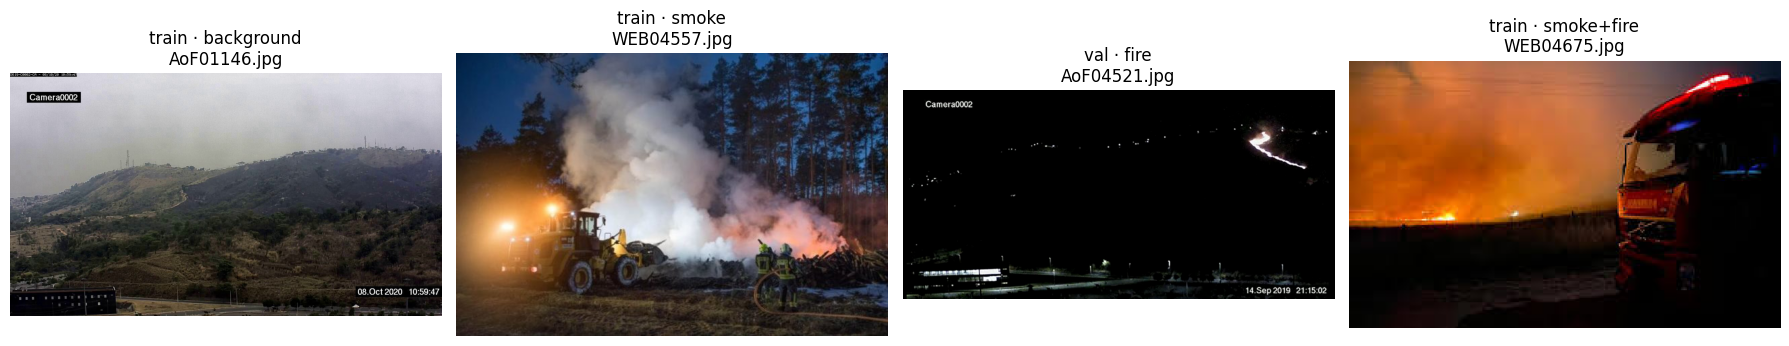

In [14]:
def show_examples(table, seed=SEED):
    selected = []
    for category in ("background", "smoke", "fire", "smoke+fire"):
        candidates = table[table["category"] == category]
        if not candidates.empty:
            selected.append(candidates.sample(1, random_state=seed))
    sample = pd.concat(selected)
    figure, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    axes = axes.ravel()
    for axis, row in zip(axes, sample.itertuples()):
        with Image.open(row.image_path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row.split} · {row.category}\n{row.filename}")
        axis.axis("off")
    for axis in axes[len(sample):]:
        axis.axis("off")
    plt.show()

show_examples(manifest[manifest["split"].isin(["train", "val"])])


## 7. Resumen final

In [15]:
display(pd.Series({
    "dataset_version": DATASET_VERSION,
    "prepared_root": str(PREPARED_ROOT),
    "manifest": str(manifest_path),
    "data_yaml": str(data_yaml_path),
    "manifest_sha256": pipeline.sha256_file(manifest_path),
    "original_modified": False,
}, name="valor").to_frame())

print("La versión preparada ya puede consumirse desde el notebook 02.")


,valor
dataset_version,dfire_seed42_val10_v1
prepared_root,/workspace/TFM/artifacts/datasets/dfire_seed42...
manifest,/workspace/TFM/artifacts/datasets/dfire_seed42...
data_yaml,/workspace/TFM/artifacts/datasets/dfire_seed42...
manifest_sha256,97442af38322abe1bf5178bd6b92c30971d9f354eca319...
original_modified,False


La versión preparada ya puede consumirse desde el notebook 02.
